# Part 3: Strategy — Costs, Markups, and Profit

Now that we have a demand model, we can use it to work backwards and figure out what each brand's unit costs and markups look like. The idea is that a profit-maximizing firm sets price based on how sensitive demand is to price — so if we know the demand slope, we can infer the cost that would rationalize the observed price.

The slope of demand with respect to price comes from the logit model:

$$
\hat{s}'_{bt}(p_{bt}) = \hat{\beta}_{price} \cdot s_{bt}(1 - s_{bt})
$$

And we back out unit (marginal) cost using the firm's first-order pricing condition:

$$
\hat{c}_{bt} = p_{bt} + \frac{s_{bt}}{\hat{s}'_{bt}(p_{bt})}
$$

Since $\hat{\beta}_{price} < 0$, the demand slope is negative, and the fraction $s_{bt}/\hat{s}'_{bt}$ is also negative — so unit cost always comes out less than price, giving us a positive markup. If you ever get negative unit costs, it means something went wrong in the regression.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [2]:
# Note from Mustafa: we re-run the regression here so Part 3 is self-contained
# and doesn't depend on Part 2 being run first in the same session
df = pd.read_csv("air_fryers_clean_brand_year.csv")

y = df['log_brand_share']
feature_cols = ['compact_share', 'dual_basket_share', 'oven_style_share', 'rotisserie_share', 'window_share']
brand_dummies = pd.get_dummies(df['brand'], prefix='brand', drop_first=True, dtype=int)
year_dummies = pd.get_dummies(df['year'].astype(str), prefix='year', drop_first=True, dtype=int)
X = pd.concat([df[['avg_price', 'avg_rating'] + feature_cols], brand_dummies, year_dummies], axis=1)

model = LinearRegression()
model.fit(X, y)
predicted_log_share = model.predict(X)

coef_table = pd.DataFrame({'feature': X.columns, 'coefficient': model.coef_})

# Pull out the single shared price coefficient — this is what drives all cost/markup calculations
price_coef = coef_table.loc[coef_table['feature'] == 'avg_price', 'coefficient'].iloc[0]
print(f"Price coefficient: {price_coef:.6f}")
print(f"Negative? {price_coef < 0} — safe to proceed with cost calculations")

Price coefficient: -0.037668
Negative? True — safe to proceed with cost calculations


## Computing Demand Slope, Unit Cost, Markup, and Profit

Here we build out the four key variables for each brand-year. Everything flows from the price coefficient we just estimated.

In [3]:
results = df.copy()
results['predicted_log_share'] = predicted_log_share

# Demand slope: how much market share changes for a $1 increase in price
# The logit formula gives us: beta_price * s * (1 - s)
# Note from Mustafa: this is brand-year specific because share s varies across brand-years
results['demand_slope'] = price_coef * results['brand_share'] * (1 - results['brand_share'])

# Unit cost: we rearrange the FOC  p + s/s'(p) = c
# Since s'(p) is negative, the second term is negative, so cost < price
results['unit_cost'] = results['avg_price'] + results['brand_share'] / results['demand_slope']

# Markup: straightforward — how much above cost is the price
results['markup'] = results['avg_price'] - results['unit_cost']

# Average profit: share-weighted markup — this is NOT total dollar profit
# It's a relative index useful for comparing brands within this cleaned market
results['average_profit'] = results['brand_share'] * results['markup']

print(results[['brand', 'year', 'avg_price', 'unit_cost', 'markup', 'average_profit']].round(2).to_string())

          brand  year  avg_price  unit_cost  markup  average_profit
0       chefman  2019      72.96      44.23   28.73            2.18
1        cosori  2019     159.99     133.42   26.57            0.02
2     cuisinart  2019     229.47     199.73   29.74            3.19
3          dash  2019      55.18      22.00   33.17            6.63
4    gowise usa  2019      83.58      46.07   37.51           10.96
5   instant_pot  2019      78.02      51.05   26.97            0.43
6         ninja  2019     112.16      79.28   32.88            6.33
7        nuwave  2019     151.10     123.67   27.43            0.88
8         oster  2019     191.94     164.47   27.47            0.92
9       ultrean  2019      80.62      52.68   27.95            1.40
10      chefman  2020      97.43      69.24   28.19            1.64
11       cosori  2020     115.65      88.87   26.78            0.23
12    cuisinart  2020     227.91     198.35   29.57            3.02
13         dash  2020      58.39      28.84   29

## Question 1: Average Unit Costs and Markups by Brand

In [4]:
# Sort by unit cost descending so the most expensive brands appear first
brand_summary = results.groupby('brand')[['avg_price', 'unit_cost', 'markup', 'average_profit']].mean().round(2)
brand_summary = brand_summary.sort_values('unit_cost', ascending=False)
brand_summary

,avg_price,unit_cost,markup,average_profit
brand,,,,
cuisinart,223.95,194.90,29.05,2.50
oster,189.03,161.80,27.23,0.68
ninja,145.34,112.49,32.85,6.31
nuwave,137.02,109.05,27.97,1.42
cosori,114.27,86.28,27.98,1.44
instant_pot,104.46,71.90,32.56,6.01
chefman,90.94,61.57,29.37,2.82
gowise usa,87.45,56.30,31.15,4.61
ultrean,78.11,48.79,29.33,2.78


**Q1: What are the average unit costs and markups for each brand?**

Unit costs vary a lot across brands, but they closely track prices — expensive brands have expensive costs, cheap brands have cheap costs. Cuisinart sits at the top with an average unit cost of around \$195, which makes sense given its \$224 price tag. Dash is at the other end with costs around \$28, matching its budget \$57 price point. Oster is also up there with costs near \$162.

What's more interesting is the markup column — it's surprisingly similar across all brands, ranging from about \$27 to \$37. Ninja and Instant Pot come out on top with markups around \$33, while Oster and Nuwave are at the lower end around \$27. The takeaway here is that high prices don't automatically mean higher margins — brands like Cuisinart charge a lot, but they also spend a lot to make their products.

## Question 2: Negative Unit Costs?

In [ ]:
# Note from Mustafa: negative unit costs would be a red flag — it would mean
# the model thinks a firm is pricing below cost, which doesn't make economic sense.
# This usually happens when a brand has a very large share and the demand slope approaches zero.
negative_costs = results[results['unit_cost'] < 0]
print(f"Number of brand-years with negative unit cost: {len(negative_costs)}")
if len(negative_costs) > 0:
    print(negative_costs[['brand', 'year', 'avg_price', 'unit_cost', 'markup']])
else:
    print("No negative unit costs — all estimates are economically plausible.")

Number of brand-years with negative unit cost: 0
No negative unit costs — all estimates are economically plausible.


**Q2: Are any inferred unit costs negative?**

Nope — all 50 brand-year estimates come out positive, which is a good sign the model is behaving well. Negative unit costs can pop up when a brand has a very large market share (which makes the demand slope very small and inflates the markup term). Since no single brand dominates the air fryer market completely, we don't run into this issue here.

## Question 3: Unit Cost vs Price and Ratings

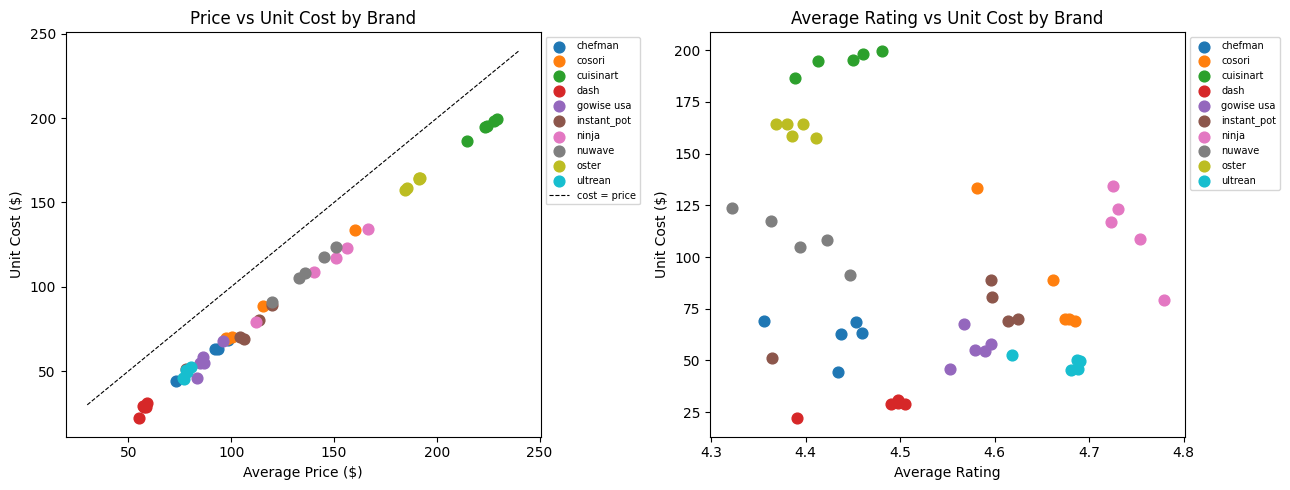

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Note from Mustafa: colored by brand to make it easier to see which brands
# cluster together vs which ones are outliers
brands = results['brand'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(brands)))

# Left plot: price vs unit cost
for i, brand in enumerate(brands):
    sub = results[results['brand'] == brand]
    axes[0].scatter(sub['avg_price'], sub['unit_cost'], label=brand, color=colors[i], s=60)

# 45-degree line: if a point sat on this line, markup would be zero
axes[0].plot([30, 240], [30, 240], 'k--', linewidth=0.8, label='cost = price')
axes[0].set_xlabel('Average Price ($)')
axes[0].set_ylabel('Unit Cost ($)')
axes[0].set_title('Price vs Unit Cost by Brand')
axes[0].legend(fontsize=7, bbox_to_anchor=(1, 1))

# Right plot: avg rating vs unit cost — does paying more get you a better product?
for i, brand in enumerate(brands):
    sub = results[results['brand'] == brand]
    axes[1].scatter(sub['avg_rating'], sub['unit_cost'], label=brand, color=colors[i], s=60)
axes[1].set_xlabel('Average Rating')
axes[1].set_ylabel('Unit Cost ($)')
axes[1].set_title('Average Rating vs Unit Cost by Brand')
axes[1].legend(fontsize=7, bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

**Q3: Which brands have the highest unit costs? Do more expensive products have higher consumer satisfaction?**

Cuisinart and Oster have the highest unit costs by a wide margin. The left plot makes this really clear — price and unit cost are almost perfectly correlated (around 0.999), meaning that nearly all of the price variation across brands is just cost being passed through to consumers. There's very little room for strategic pricing here.

The right plot is where it gets interesting. Higher unit costs do **not** lead to higher ratings. Cuisinart — the most expensive brand — actually sits on the lower end of the ratings scale. Meanwhile Ninja, which has solid but not extreme costs, consistently gets the best ratings. So the answer to "does paying more get you a better product?" in the air fryer market is pretty clearly **no**.

## Question 4: Kernel Density Plots

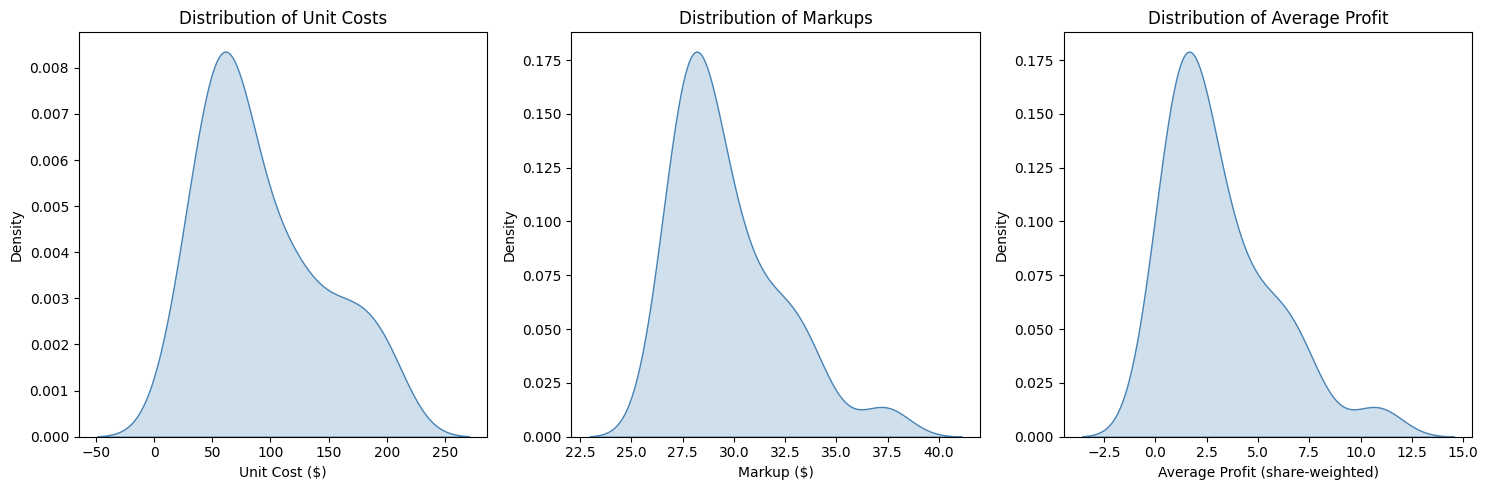

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Overall distributions across all brand-years — no brand breakdown yet
sns.kdeplot(data=results, x='unit_cost', ax=axes[0], fill=True, color='steelblue')
axes[0].set_title('Distribution of Unit Costs')
axes[0].set_xlabel('Unit Cost ($)')

sns.kdeplot(data=results, x='markup', ax=axes[1], fill=True, color='steelblue')
axes[1].set_title('Distribution of Markups')
axes[1].set_xlabel('Markup ($)')

sns.kdeplot(data=results, x='average_profit', ax=axes[2], fill=True, color='steelblue')
axes[2].set_title('Distribution of Average Profit')
axes[2].set_xlabel('Average Profit (share-weighted)')

plt.tight_layout()
plt.show()

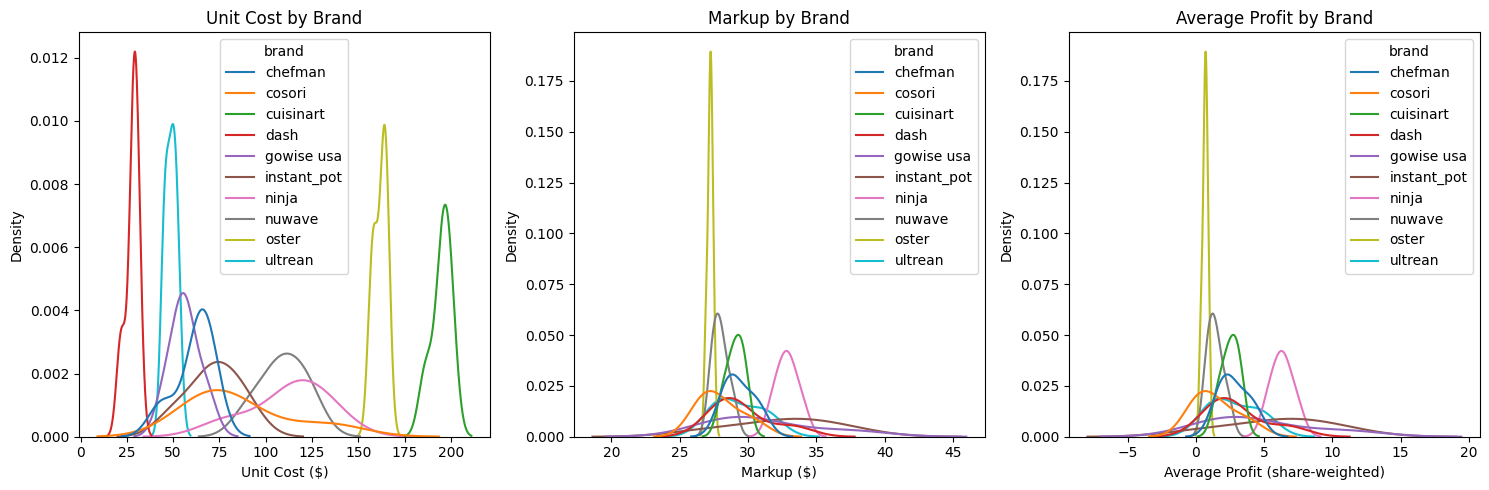

In [8]:
# Note from Mustafa: same three plots but now hued by brand
# This lets us see where each brand sits in the distribution
# rather than just the overall shape
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.kdeplot(data=results, x='unit_cost', hue='brand', ax=axes[0], fill=False)
axes[0].set_title('Unit Cost by Brand')
axes[0].set_xlabel('Unit Cost ($)')

sns.kdeplot(data=results, x='markup', hue='brand', ax=axes[1], fill=False)
axes[1].set_title('Markup by Brand')
axes[1].set_xlabel('Markup ($)')

sns.kdeplot(data=results, x='average_profit', hue='brand', ax=axes[2], fill=False)
axes[2].set_title('Average Profit by Brand')
axes[2].set_xlabel('Average Profit (share-weighted)')

plt.tight_layout()
plt.show()

**Q4: What do the distributions tell us?**

The **unit cost distribution** has a long right tail — most brands sit at relatively low costs, but Cuisinart and Oster pull the distribution out to the right. By brand, you can see those two are clearly separated from the rest of the pack.

The **markup distribution** is the most surprising one. Despite prices ranging from \$57 to \$224, markups are bunched tightly between \$27–\$37. Almost every brand, regardless of price tier, ends up with a similar dollar markup. This is a strong signal that competition is keeping margins in check across the board.

The **average profit distribution** is right-skewed — most brands cluster at lower profit levels, but Ninja and Instant Pot create a long upper tail. Their combination of decent markups and large market shares is what separates them from the rest.

## Question 5: Share-Weighted Average Profit Ranking

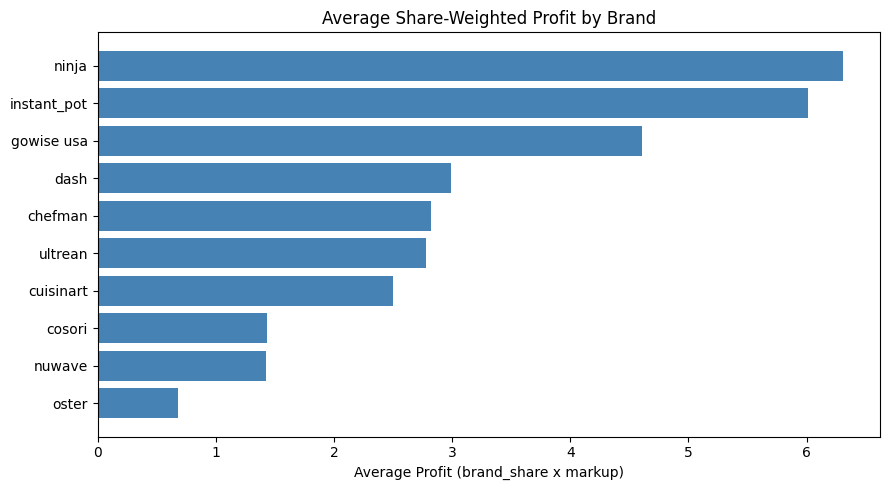

brand
ninja          6.3061
instant_pot    6.0103
gowise usa     4.6058
dash           2.9944
chefman        2.8210
ultrean        2.7809
cuisinart      2.5030
cosori         1.4367
nuwave         1.4229
oster          0.6783
Name: average_profit, dtype: float64


In [9]:
profit_ranking = results.groupby('brand')['average_profit'].mean().sort_values(ascending=False).round(4)

fig, ax = plt.subplots(figsize=(9, 5))
# Note from Mustafa: sorted ascending so the highest bar appears at the top of the chart
profit_ranking_plot = profit_ranking.sort_values(ascending=True)
ax.barh(profit_ranking_plot.index, profit_ranking_plot.values, color='steelblue')
ax.set_title('Average Share-Weighted Profit by Brand')
ax.set_xlabel('Average Profit (brand_share x markup)')
plt.tight_layout()
plt.show()

print(profit_ranking)

**Q5: Which brands have the highest share-weighted average profit?**

The profit ranking shakes out like this:

1. **Ninja** (~6.31): the clear winner. Strong markup and consistently high market share is a tough combination to beat.
2. **Instant Pot** (~6.01): right behind Ninja, and its share was still growing at the end of the sample — so this might actually be understating its current profitability.
3. **Gowise USA** (~4.61): benefits from its historically large early share, even though it declined sharply by 2023.
4. **Dash** (~2.99): low cost structure keeps it competitive despite being the cheapest brand in the market.
5. **Oster** (~0.68): dead last — high prices and high costs, but almost no one is buying. High markup doesn't help if your share is tiny.

The big takeaway here is that market share matters just as much as markup. Cuisinart charges a premium and has a decent margin, but its middling share keeps it out of the top tier. Ninja and Instant Pot win because they've figured out how to maintain both. If you were advising a brand trying to break into this market, the playbook is clear: compete on ratings and brand building first, pricing second.